In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('dataset.csv')
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [ ]:
print(df["Target"].unique())

['Dropout' 'Graduate' 'Enrolled']


In [ ]:
df["Target"] = df["Target"].astype(str).str.strip().str.capitalize()
print(df["Target"].unique())

['Dropout' 'Graduate' 'Enrolled']


In [ ]:
df["Target"] = df["Target"].map({
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
})
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,2
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,0
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,2


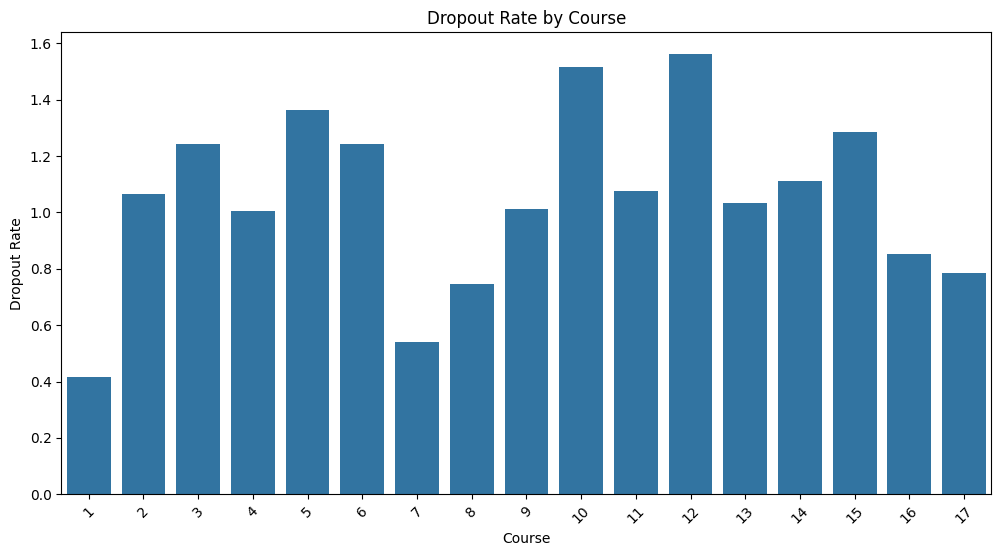

In [ ]:
dropout_by_course = (
    df.groupby("Course")["Target"]
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(12,6))
sns.barplot(
    x=dropout_by_course.index,
    y=dropout_by_course.values
)

plt.title("Dropout Rate by Course")
plt.xlabel("Course")
plt.ylabel("Dropout Rate")
plt.xticks(rotation=45)
plt.show()

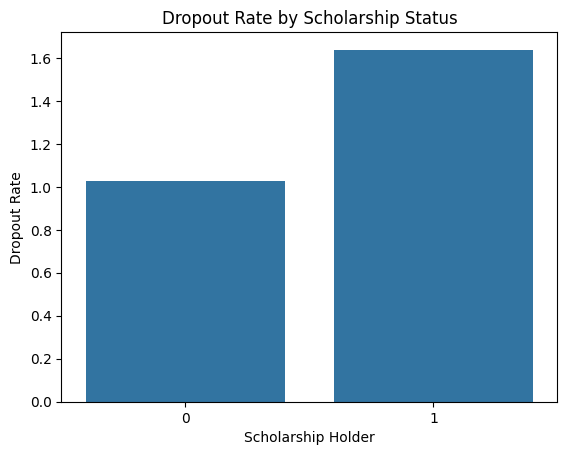

In [ ]:
scholarship_dropout = (
    df.groupby("Scholarship holder")["Target"]
    .mean()
)

sns.barplot(
    x=scholarship_dropout.index,
    y=scholarship_dropout.values
)

plt.title("Dropout Rate by Scholarship Status")
plt.xlabel("Scholarship Holder")
plt.ylabel("Dropout Rate")
plt.show()

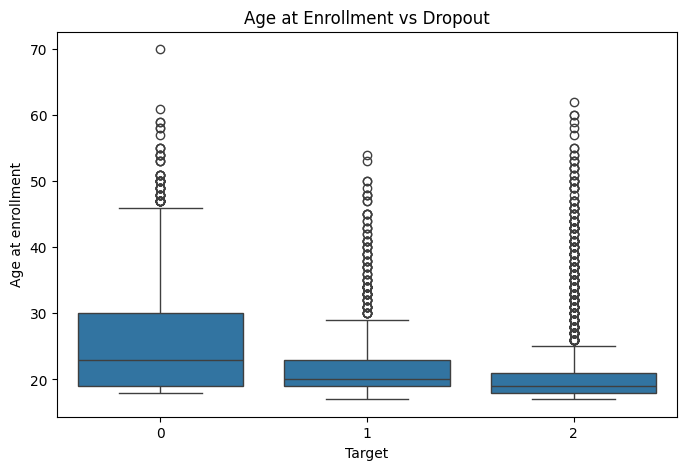

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Target",
    y="Age at enrollment",
    data=df
)

plt.title("Age at Enrollment vs Dropout")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('dataset.csv')

df['grade_ratio'] = (
    df['Curricular units 1st sem (grade)'] /
    (df['Curricular units 2nd sem (grade)'] + 1)
)

df['approval_rate_1st'] = (
    df['Curricular units 1st sem (approved)'] /
    (df['Curricular units 1st sem (enrolled)'] + 1)
)

df['approval_rate_2nd'] = (
    df['Curricular units 2nd sem (approved)'] /
    (df['Curricular units 2nd sem (enrolled)'] + 1)
)

df['performance_trend'] = (
    df['Curricular units 2nd sem (grade)'] -
    df['Curricular units 1st sem (grade)']
)

df['financial_stress'] = (
    (df['Tuition fees up to date'] == 0) &
    (df['Scholarship holder'] == 0)
).astype(int)

df['economic_pressure'] = df['Unemployment rate'] * df['Inflation rate']
df["financial_stability"] = df["Scholarship holder"] * df["Tuition fees up to date"]
df["financial_risk"] = df["Debtor"] * (1 - df["Tuition fees up to date"])
df["no_support_risk"] = (1 - df["Scholarship holder"]) * df["Debtor"]

df['Target'] = df['Target'].str.strip().map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})
df = df.dropna(subset=['Target'])
df['Target'] = df['Target'].astype(int)

numerical_cols = [
    'Age at enrollment', 'grade_ratio', 'approval_rate_1st',
    'approval_rate_2nd', 'performance_trend', 'economic_pressure',
    'Unemployment rate', 'GDP'
]

categorical_cols = [
    'Course', 'Gender', 'Scholarship holder',
    'Tuition fees up to date', 'financial_stress'
]

feature_cols = numerical_cols + categorical_cols

X = df[feature_cols]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("Target distribution:\n", y.value_counts())

X_train shape: (3539, 13)
Target distribution:
 Target
0    3003
1    1421
Name: count, dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

numerical_cols = [
    'Age at enrollment', 'grade_ratio', 'approval_rate_1st',
    'approval_rate_2nd', 'performance_trend', 'economic_pressure',
    'Unemployment rate', 'GDP'
]

categorical_cols = [
    'Course', 'Gender', 'Scholarship holder',
    'Tuition fees up to date', 'financial_stress'
]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())
    ]), categorical_cols)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: 0.9061 ± 0.0129
Gradient Boosting: 0.9105 ± 0.0134
Random Forest: 0.9037 ± 0.0117
XGBoost: 0.8911 ± 0.0090


SVM can be used here but it  is going to be significantly slower than the others on this dataset

we will try try to improve the results

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder

numerical_cols = [
    'Age at enrollment', 'grade_ratio', 'approval_rate_1st',
    'approval_rate_2nd', 'performance_trend', 'economic_pressure',
    'Unemployment rate', 'GDP'
]

categorical_cols = [
    'Course', 'Gender', 'Scholarship holder',
    'Tuition fees up to date', 'financial_stress'
]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
]), categorical_cols)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: 0.9128 ± 0.0135
Gradient Boosting: 0.9107 ± 0.0143
Random Forest: 0.9033 ± 0.0123
XGBoost: 0.9121 ± 0.0128


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


X = df.drop(columns=["Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=600,
        learning_rate=0.02,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)
xgb.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)
xgb_pred = xgb.predict(X_test)

log_proba = log_reg.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, log_proba))

print("XGBoost ROC-AUC:",
      roc_auc_score(y_test, xgb_proba))
print("Logistic Regression")
print(confusion_matrix(y_test, log_pred))

print("\nXGBoost")
print(confusion_matrix(y_test, xgb_pred))

Logistic Regression ROC-AUC: 0.9272515291415715
XGBoost ROC-AUC: 0.9362154624920906
Logistic Regression
[[569  32]
 [ 74 210]]

XGBoost
[[563  38]
 [ 65 219]]


In [ ]:
xgb_model = xgb.named_steps["model"]

import pandas as pd

importance = pd.Series(
    xgb_model.feature_importances_,
    index=xgb.named_steps["preprocessor"].get_feature_names_out()
)

print(importance.sort_values(ascending=False).head(20))

num__approval_rate_2nd            0.151283
cat__Tuition fees up to date_1    0.095440
cat__Course_2                     0.078811
cat__financial_stress_1           0.078523
cat__financial_stress_0           0.077255
cat__Tuition fees up to date_0    0.072188
num__approval_rate_1st            0.066775
cat__Course_16                    0.023539
cat__Scholarship holder_0         0.022574
cat__Course_8                     0.021045
num__Age at enrollment            0.019998
cat__Scholarship holder_1         0.019097
cat__Course_15                    0.017665
cat__Gender_0                     0.016507
cat__Course_11                    0.015701
cat__Course_17                    0.015625
cat__Course_10                    0.015011
cat__Course_9                     0.014826
num__grade_ratio                  0.014816
cat__Course_14                    0.014508
dtype: float32


Based on these results, I'd create features that combine the strongest signals.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('dataset.csv')

df['grade_ratio'] = (
    df['Curricular units 1st sem (grade)'] /
    (df['Curricular units 2nd sem (grade)'] + 1)
)

df['approval_rate_1st'] = (
    df['Curricular units 1st sem (approved)'] /
    (df['Curricular units 1st sem (enrolled)'] + 1)
)

df['approval_rate_2nd'] = (
    df['Curricular units 2nd sem (approved)'] /
    (df['Curricular units 2nd sem (enrolled)'] + 1)
)

df['performance_trend'] = (
    df['Curricular units 2nd sem (grade)'] -
    df['Curricular units 1st sem (grade)']
)

df['financial_stress'] = (
    (df['Tuition fees up to date'] == 0) &
    (df['Scholarship holder'] == 0)
).astype(int)

df['economic_pressure'] = df['Unemployment rate'] * df['Inflation rate']
df["financial_stability"] = df["Scholarship holder"] * df["Tuition fees up to date"]
df["financial_risk"] = df["Debtor"] * (1 - df["Tuition fees up to date"])
df["no_support_risk"] = (1 - df["Scholarship holder"]) * df["Debtor"]
df["academic_financial_risk"] = (
    (1 - df["approval_rate_2nd"])
    * df["financial_stress"]
)
df["tuition_performance"] = (
    df["approval_rate_2nd"]
    * df["Tuition fees up to date"]
)
df["approval_improvement"] = (
    df["approval_rate_2nd"]
    - df["approval_rate_1st"]
)
df["age_academic_risk"] = (
    df["Age at enrollment"]
    * (1 - df["approval_rate_2nd"])
)

df['Target'] = df['Target'].str.strip().map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})
df = df.dropna(subset=['Target'])
df['Target'] = df['Target'].astype(int)

numerical_cols = [
    'Age at enrollment',
    'grade_ratio',
    'approval_rate_1st',
    'approval_rate_2nd',
    'performance_trend',
    'economic_pressure',
    'GDP',
    'academic_financial_risk',
    'approval_improvement',
    'age_academic_risk'
]

categorical_cols = [
    'Course', 'Gender', 'Scholarship holder',
    'Tuition fees up to date', 'financial_stress'
]

feature_cols = numerical_cols + categorical_cols

X = df[feature_cols]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("Target distribution:\n", y.value_counts())

numerical_cols = [
    'Age at enrollment',
    'grade_ratio',
    'approval_rate_1st',
    'approval_rate_2nd',
    'performance_trend',
    'economic_pressure',
    'GDP',
    'academic_financial_risk',
    'approval_improvement',
    'age_academic_risk'
]
categorical_cols = [
    'Course', 'Gender', 'Scholarship holder',
    'Tuition fees up to date', 'financial_stress'
]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
]), categorical_cols)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

X_train shape: (3539, 15)
Target distribution:
 Target
0    3003
1    1421
Name: count, dtype: int64
Logistic Regression: 0.9125 ± 0.0135
Gradient Boosting: 0.9148 ± 0.0137
Random Forest: 0.9073 ± 0.0111
XGBoost: 0.9145 ± 0.0127


we see some improvemens  in XGboost


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


X = df.drop(columns=["Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=600,
        learning_rate=0.02,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)
xgb.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)
xgb_pred = xgb.predict(X_test)

log_proba = log_reg.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, log_proba))

print("XGBoost ROC-AUC:",
      roc_auc_score(y_test, xgb_proba))
print("Logistic Regression")
print(confusion_matrix(y_test, log_pred))

print("\nXGBoost")
print(confusion_matrix(y_test, xgb_pred))

Logistic Regression ROC-AUC: 0.9263141243467461
XGBoost ROC-AUC: 0.9382426003609008
Logistic Regression
[[567  34]
 [ 72 212]]

XGBoost
[[563  38]
 [ 60 224]]


In [ ]:
def assign_risk_tier(probability):
    if probability >= 0.70:
        return "High Risk", "Immediate advisor intervention recommended"
    elif probability >= 0.40:
        return "Medium Risk", "Schedule check-in within 2 weeks"
    else:
        return "Low Risk", "Standard monitoring"

y_test_reset = y_test.reset_index(drop=True)
probs = xgb.predict_proba(X_test)[:, 1]
results = pd.DataFrame({
    'dropout_probability': probs,
    'risk_tier': [assign_risk_tier(p)[0] for p in probs],
    'recommendation': [assign_risk_tier(p)[1] for p in probs]
})


print(results['risk_tier'].value_counts())
print(f"\nHigh-risk students: {(results['risk_tier'] == 'High Risk').sum()}")
print(f"Of those, actual dropouts: {y_test_reset[results['risk_tier'] == 'High Risk'].sum()}")

risk_tier
Low Risk       593
High Risk      213
Medium Risk     79
Name: count, dtype: int64

High-risk students: 213
Of those, actual dropouts: 196
